In [1]:
import numpy as np
import pandas as pd
from collections import Counter
import warnings
import os

warnings.filterwarnings('ignore')
pd.options.display.float_format = '{:.4f}'.format

In [2]:
#representations
#sex: Female 0, Male 1
#illnessseverityoninitialasse: Mild 0, Moderate 1, Severe 2, Critical 3
#ardsseverity: na 0, mild 1, moderate 2, severe 3
df = pd.read_excel('input.xlsx')

In [3]:
df.head()

,age,sex,anycomorbidillness,cmconsideredinmoderate,dm,hpn,heartdisease,chronicliverdisease,chronickidneydisease,copd,...,therapy_interferon,therapy_favipiravir,therapy_hcqorcq,therapy_cq,therapy_hcq,therapy_lpvr,therapy_cpt,outcome_mortality,finalseverity,initialseverity
0,34,0,1,1,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Mild/Moderate,Mild/Moderate
1,53,1,1,1,1,1,0,0,0,0,...,0,0,0,0,0,0,0,0,Mild/Moderate,Mild/Moderate
2,44,0,1,1,1,1,1,0,1,0,...,0,0,0,0,0,1,0,0,Severe/Critical,Severe/Critical
3,42,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,Mild/Moderate,Mild/Moderate
4,47,0,1,1,1,1,0,0,0,0,...,0,0,0,0,0,0,0,0,Mild/Moderate,Mild/Moderate


In [4]:
df.shape

(1212, 35)

In [5]:
df.isnull().sum()

age                             0
sex                             0
anycomorbidillness              0
cmconsideredinmoderate          0
dm                              0
hpn                             0
heartdisease                    0
chronicliverdisease             0
chronickidneydisease            0
copd                            0
asthma                          0
activetb                        0
hiv                             0
cancer                          0
neurologicdisease               0
otherillnesses                  0
pregnant                        0
illnessseverityoninitialasse    0
finalillnessseverity            0
ardsseverity                    0
therapy_hemoperfusion           0
therapy                         0
soc                             0
therapy_toci                    0
therapy_remdesivir              0
therapy_interferon              0
therapy_favipiravir             0
therapy_hcqorcq                 0
therapy_cq                      0
therapy_hcq   

In [6]:
# therapy_favipiravir has 0 values only; did not include in model 
df.drop(columns=['anycomorbidillness', 'cmconsideredinmoderate', 'otherillnesses',
                 'finalillnessseverity', 'finalseverity', 'therapy_favipiravir', 
                 'initialseverity'], inplace=True)

In [7]:
df.head()

,age,sex,dm,hpn,heartdisease,chronicliverdisease,chronickidneydisease,copd,asthma,activetb,...,soc,therapy_toci,therapy_remdesivir,therapy_interferon,therapy_hcqorcq,therapy_cq,therapy_hcq,therapy_lpvr,therapy_cpt,outcome_mortality
0,34,0,1,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
1,53,1,1,1,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
2,44,0,1,1,1,0,1,0,0,0,...,0,0,0,0,0,0,0,1,0,0
3,42,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
4,47,0,1,1,0,0,0,0,1,0,...,1,0,0,0,0,0,0,0,0,0


In [8]:
df.dtypes

age                             int64
sex                             int64
dm                              int64
hpn                             int64
heartdisease                    int64
chronicliverdisease             int64
chronickidneydisease            int64
copd                            int64
asthma                          int64
activetb                        int64
hiv                             int64
cancer                          int64
neurologicdisease               int64
pregnant                        int64
illnessseverityoninitialasse    int64
ardsseverity                    int64
therapy_hemoperfusion           int64
therapy                         int64
soc                             int64
therapy_toci                    int64
therapy_remdesivir              int64
therapy_interferon              int64
therapy_hcqorcq                 int64
therapy_cq                      int64
therapy_hcq                     int64
therapy_lpvr                    int64
therapy_cpt 

In [9]:
convert_cat_cols = ['sex', 'dm', 'hpn', 'heartdisease', 'chronicliverdisease', 'chronickidneydisease', 'copd', 
                    'asthma', 'activetb', 'hiv', 'cancer', 'neurologicdisease', 'pregnant', 'illnessseverityoninitialasse',
                    'ardsseverity', 'therapy_hemoperfusion', 'therapy', 'soc', 'therapy_toci', 'therapy_remdesivir',
                    'therapy_interferon', 'therapy_hcqorcq', 'therapy_cq', 'therapy_hcq', 
                    'therapy_lpvr', 'therapy_cpt', 'outcome_mortality']
df[convert_cat_cols] = df[convert_cat_cols].astype('category');

In [10]:
df.dtypes

age                                int64
sex                             category
dm                              category
hpn                             category
heartdisease                    category
chronicliverdisease             category
chronickidneydisease            category
copd                            category
asthma                          category
activetb                        category
hiv                             category
cancer                          category
neurologicdisease               category
pregnant                        category
illnessseverityoninitialasse    category
ardsseverity                    category
therapy_hemoperfusion           category
therapy                         category
soc                             category
therapy_toci                    category
therapy_remdesivir              category
therapy_interferon              category
therapy_hcqorcq                 category
therapy_cq                      category
therapy_hcq     

In [24]:
import matplotlib.pyplot as plt
%matplotlib inline

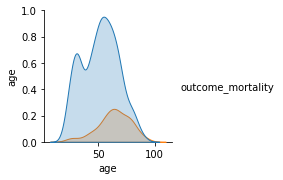

In [25]:
import seaborn as sns
sns.pairplot(data=df, hue='outcome_mortality', palette='tab10');

In [23]:
cm = sns.light_palette("green", as_cmap=True)
d = df.corr().abs()
s = d.style.background_gradient(cmap=cm)
display(s)

,age
age,1.000000


In [12]:
X = df.drop(columns=['outcome_mortality'])
y = df[['outcome_mortality']]

In [ ]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler

# scaler = MinMaxScaler()
scaler = StandardScaler()

cols = X.columns
X = pd.DataFrame(scaler.fit_transform(X))
X.columns = cols

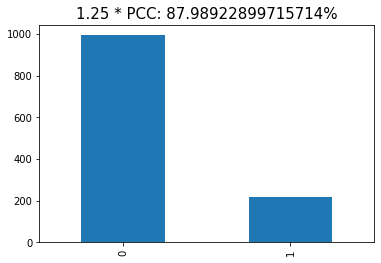

In [13]:
state_counts = Counter(df['outcome_mortality'])
df_state = pd.DataFrame.from_dict(state_counts, orient='index')
df_state.plot(kind='bar', colormap='tab10')

pcc1 = (df_state[0]/df_state[0].sum())**2
score_to_beat = 1.25*100*pcc1.sum()
plt.title("1.25 * PCC: {}%".format(score_to_beat), fontsize= 15);
plt.legend().set_visible(False)

In [17]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split


def train_KNN(X, y, n_neighbors=20, random_states=10):

    res = pd.DataFrame(
        columns=['n_neighbors', 'mean train score', 'std train score',
                 'mean test score', 'std test score'])

    #i = n_neighbors
    for i in range(1, n_neighbors+1):
        train_scores = []
        test_scores = []

        #ii = random_state
        for ii in range(0, random_states):
            X_train, X_test, y_train, y_test = train_test_split(
                X, y, test_size=0.25, random_state=ii)

            clf = KNeighborsClassifier(n_neighbors=i)
            clf.fit(X_train, y_train)

            train_scores.append(clf.score(X_train, y_train))
            test_scores.append(clf.score(X_test, y_test))

        res.loc[i] = [i, np.mean(train_scores) * 100,
                      np.std(train_scores),
                      np.mean(test_scores)*100,
                      np.std(test_scores)]
    summary_ = ['KNN',
                res['mean test score'].max(),
                'N_Neighbor = {0}'.format(
                    res['n_neighbors'][res['mean test score'].idxmax()]),
                'NA']
    
    fc = pd.DataFrame(columns=['features', 'coeff'])
    
    return summary_, fc

def train_Linear(X, y, C, ml_method='Logistic', penalty='l1', random_states=10):

    res = pd.DataFrame(
        columns=['C', 'mean train score', 'std train score',
                 'mean test score', 'std test score', 'Top Predictor Variable'])

    weighted_coefs = []

    for i in C:
        train_scores = []
        test_scores = []
        coefs = []

        #ii = random_state
        for ii in range(0, random_states):
            X_train, X_test, y_train, y_test = train_test_split(
                X, y, test_size=0.25, random_state=ii)

            if ml_method == 'Logistic':
                clf = LogisticRegression(C=i, penalty=penalty, solver='liblinear')
            elif ml_method == 'Linear SVM':
                if penalty == "l1":
                    clf = LinearSVC(C=i, penalty="l1",
                                    loss='squared_hinge', dual=False)
                else:
                    clf = LinearSVC(C=i, penalty="l2")
            else:
                raise ValueError('ml_method not recognized')

            clf.fit(X_train, y_train)

            train_scores.append(clf.score(X_train, y_train))
            test_scores.append(clf.score(X_test, y_test))
            coefs.append(np.absolute(clf.coef_[0]))

            # store feature coefficients for this C value
            if i == 0.1:
                weighted_coefs.append(clf.coef_)

        res.loc[i] = [i, np.mean(train_scores) * 100,
                      np.std(train_scores),
                      np.mean(test_scores)*100,
                      np.std(test_scores),
                      list(X)[np.argmax(np.mean(coefs, axis=0))]]

    # store feature coefficients in a dataframe
    mean_coefs = np.mean(weighted_coefs, axis=0)
    fc = pd.DataFrame(columns=['features', 'coeff'])
    fc['features'] = list(X)
    fc['coeff'] = np.abs(mean_coefs[0]).tolist()
    fc.set_index('features', inplace=True)
    fc = fc.sort_values('coeff')

    # results summary for max test score
    summary_ = ['{0} {1}'.format(ml_method, penalty),
                res['mean test score'].max(),
                'C = {0}'.format(
        res['C'][res['mean test score'].idxmax()]),
        res['Top Predictor Variable'][res.index[res['C'] == 0.1].tolist()[0]]]

    return summary_, fc

def train_Tree(X, y, ml_method='Decision Tree', depth=5, random_states=10):

    res = pd.DataFrame(
        columns=['depth', 'mean train score', 'std train score',
                 'mean test score', 'std test score', 'mean_coef'])

    #i = depth
    for i in range(2, depth+1):
        train_scores = []
        test_scores = []
        coefs = []

        #ii = random_state
        for ii in range(0, random_states):
            X_train, X_test, y_train, y_test = train_test_split(
                X, y, test_size=0.25, random_state=ii)
            
            if ml_method == 'Decision Tree':
                clf = DecisionTreeClassifier(max_depth=i, random_state=10)
            elif ml_method == 'Random Forest':
                clf = RandomForestClassifier(max_depth=i, random_state=10, n_estimators=100)
            elif ml_method == 'GBM':
                clf = GradientBoostingClassifier(max_depth=i, random_state=0, learning_rate=0.1)
            else:
                raise ValueError('ml_method not recognized')
            
            clf.fit(X_train, y_train)

            train_scores.append(clf.score(X_train, y_train))
            test_scores.append(clf.score(X_test, y_test))
            coefs.append(clf.feature_importances_)
                
        res.loc[i] = [i, np.mean(train_scores) * 100,
                      np.std(train_scores),
                      np.mean(test_scores)*100,
                      np.std(test_scores),
                      np.mean(coefs, axis=0)]
    
    mean_coefs = res['mean_coef'][res['mean test score'].idxmax()]
    fc = pd.DataFrame(columns=['features', 'coeff'])
    fc['features'] = list(X)
    fc['coeff'] = np.abs(mean_coefs).tolist()
    fc.set_index('features', inplace=True)
    fc = fc.sort_values('coeff')
    
    summary_ = [ml_method,
                res['mean test score'].max(),
                'depth = {0}'.format(res['depth'][res['mean test score'].idxmax()]),
                fc['coeff'].idxmax()]

    return summary_, fc

In [18]:
C = [1e-8, 1e-4, 1e-3, 1e-2, 0.1, 0.2, 0.4, 0.75, 1, 1.5, 3, 5, 10, 15,  20, 100, 300, 1000, 5000]

results = []

results.append(train_KNN(X, y['outcome_mortality']))
results.append(train_Linear(X, y['outcome_mortality'], C, ml_method='Logistic', penalty='l2'))
results.append(train_Linear(X, y['outcome_mortality'], C, ml_method='Logistic', penalty='l1'))
results.append(train_Linear(X, y['outcome_mortality'], C, ml_method='Linear SVM', penalty='l2'))
results.append(train_Linear(X, y['outcome_mortality'], C, ml_method='Linear SVM', penalty='l1'))
results.append(train_Tree(X, y['outcome_mortality'], ml_method='Decision Tree', depth=5))
results.append(train_Tree(X, y['outcome_mortality'], ml_method='Random Forest', depth=5))
results.append(train_Tree(X, y['outcome_mortality'], ml_method='GBM', depth=5))

In [19]:
df2 = pd.DataFrame(columns=['Machine Learning Method', 'Test Accuracy',
        'Best Parameter', 'Top Predictor Variable'])

for i in range(8):
    df2.loc[i] = results[i][0]

print("1.25 * PCC: {}%".format(score_to_beat))
display(df2)

1.25 * PCC: 87.98922899715714%


,Machine Learning Method,Test Accuracy,Best Parameter,Top Predictor Variable
0,KNN,84.2244,N_Neighbor = 9.0,NA
1,Logistic l2,86.3366,C = 20.0,ardsseverity
2,Logistic l1,86.4026,C = 0.1,ardsseverity
3,Linear SVM l2,86.4026,C = 0.1,therapy_interferon
4,Linear SVM l1,86.2376,C = 0.1,therapy_interferon
5,Decision Tree,86.6997,depth = 2,ardsseverity
6,Random Forest,84.5875,depth = 5,ardsseverity
7,GBM,85.6436,depth = 2,ardsseverity


,logistic L2,logistic L1,Linear SVM L2,Linear SVM L1,Decision Tree,Random Forest,GBM
Feature,,,,,,,
activetb,0.3006,0.0000,0.3799,0.1826,0.0000,0.0467,0.0267
age,0.0101,0.0047,0.0090,0.0125,0.0000,0.4101,0.1954
ardsseverity,1.0000,1.0000,0.5431,0.8314,1.0000,1.0000,1.0000
asthma,0.3257,0.0000,0.1916,0.0250,0.0000,0.0188,0.0072
cancer,0.3982,0.0000,0.4074,0.2937,0.0000,0.0511,0.0327
chronickidneydisease,0.2405,0.0000,0.1707,0.1153,0.0000,0.0324,0.0101
chronicliverdisease,0.0096,0.0000,0.0563,0.0000,0.0000,0.0071,0.0002
copd,0.2524,0.0000,0.1778,0.0135,0.0000,0.0330,0.0037
dm,0.0282,0.0000,0.0367,0.0108,0.0000,0.0344,0.0010


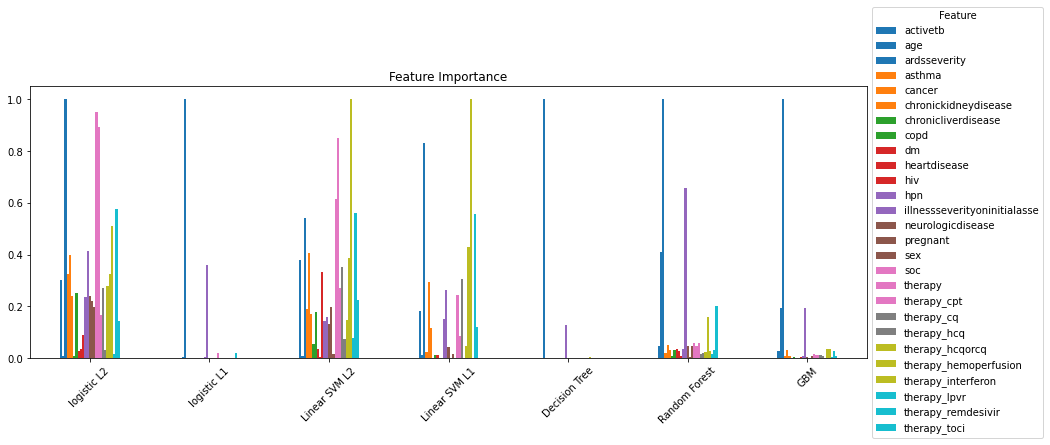

In [20]:
dfz = pd.DataFrame(columns=['Feature', 'logistic L2', 'logistic L1',
                            'Linear SVM L2', 'Linear SVM L1', 'Decision Tree', 'Random Forest', 'GBM'])

dfz['Feature'] = sorted(list(X))

for i in range(1, len(list(dfz))):
    dfz.iloc[:, i] = [x/max(results[i][1].sort_index()['coeff'].tolist()) for x in results[i][1].sort_index()['coeff'].tolist()]

dfz.set_index('Feature', inplace=True)
display(dfz)

dfz = dfz.T

dfz.plot(kind='bar', figsize=(15, 5), colormap='tab10')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5), title="Feature")
plt.xticks(rotation=45)
plt.title('Feature Importance');

In [29]:
#baseline
# res = train_Tree(X, y['Score'], ml_method='GBM', depth=5, learning_rate=0.1, 
#                  random_states=10, max_features=0.5, min_samples_leaf=4)

res = train_Tree(X, y['outcome_mortality'], ml_method='Decision Tree', depth=5)

max_res = res

Xcopy = X.copy()
cols = X.columns.tolist()

#iterate through columns and check if we can drop some features yet maintain or increase accuracy
for i in range(len(X.columns.tolist())):
    Xtemp = Xcopy.copy()
    #try drop
    print('trying to drop "{}"...'.format(cols[i]), end="")
    Xtemp.drop(columns=[cols[i]], inplace=True)
    
#     r = train_Tree(Xtemp, y['Score'], ml_method='GBM', depth=5, learning_rate=0.1, 
#                  random_states=10, max_features=0.5, min_samples_leaf=4)
    
    r = train_Tree(X, y['outcome_mortality'], ml_method='Decision Tree', depth=5)
    
    #if test accuracy >= max_accu
    if r[0][1] >= max_res[0][1]:
        Xcopy = Xtemp.copy()
        max_res = r
        print('drop successful. New max_accu = {}'.format(max_res[0][1]))
    else:
        print('drop failed')

trying to drop "age"...drop successful. New max_accu = 86.6996699669967
trying to drop "sex"...drop successful. New max_accu = 86.6996699669967
trying to drop "dm"...drop successful. New max_accu = 86.6996699669967
trying to drop "hpn"...drop successful. New max_accu = 86.6996699669967
trying to drop "heartdisease"...drop successful. New max_accu = 86.6996699669967
trying to drop "chronicliverdisease"...drop successful. New max_accu = 86.6996699669967
trying to drop "chronickidneydisease"...drop successful. New max_accu = 86.6996699669967
trying to drop "copd"...drop successful. New max_accu = 86.6996699669967
trying to drop "asthma"...drop successful. New max_accu = 86.6996699669967
trying to drop "activetb"...drop successful. New max_accu = 86.6996699669967
trying to drop "hiv"...drop successful. New max_accu = 86.6996699669967
trying to drop "cancer"...drop successful. New max_accu = 86.6996699669967
trying to drop "neurologicdisease"...drop successful. New max_accu = 86.69966996699